# California House Pricing

Fetch the dataset and separate them into inputs, targets and test sets.

In [280]:
import keras.src.datasets.california_housing
import matplotlib.pyplot as plt
import numpy as np
from keras.callbacks import EarlyStopping
from keras.layers import Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.regularizers import l2

(inputs, targets), (x_test, y_test) = keras.src.datasets.california_housing.load_data(version='small',
                                        test_split=0.2)
print(inputs.shape, targets.shape)
print(x_test.shape, y_test.shape)

(480, 8) (480,)
(120, 8) (120,)


The dataset is divided into separate training validation sets>

- Training set: First 380 samples (about 75% of the training data)
- Validation set: Remaining samples (about 25% of the training data)

In [281]:
x_train = inputs[:380]
y_train = targets[:380]
x_val = inputs[380:]
y_val = targets[380:]

### Data Normalization

The features and target values are normalized to improve model training:

- Calculate mean and standard deviation from training data.
- Subtract mean and divide by standard deviation
- Apply same normalization to validation and test sets

In [282]:
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)
x_train -= mean
x_train /= std
x_test -= mean
x_test /= std
x_val -= mean
x_val /= std
y_train /= 1e5
y_test /= 1e5
y_val /= 1e5

### Model Setup

Here I create a neural network with:
- Input layer: Input layer that accepts 8 features
- Hidden Layers: 3 hidden layers with 64 neurons, ReLU activation function and l2 regularizer to prevent overfitting
- Output Layer: Single neuron for regression.

The model uses:
- Loss Function: Mean Squared Error (MSE)
- Metrics: Mean Absolute ERROR (MAE)
- Optimizer: Adam
- Early Stopping: Stops the training when loss stops improving after 6 epochs.

In [283]:
model = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1)
])

early_stop = EarlyStopping(monitor='loss', patience=6)


model.compile(optimizer='adam', loss='mse', metrics=['mae'])

Here the model is trained and stored in history variable with 100 epochs, 32 batch size, validation data set as x_val and y_val and early_stop callback.

In [284]:
history = model.fit(x_train, y_train, epochs=160, batch_size=32, validation_data=(x_val, y_val), callbacks=[early_stop])

Epoch 1/160
12/12 [==============================] - 0s 5ms/step - loss: 4.9955 - mae: 1.5848 - val_loss: 3.1290 - val_mae: 0.9690
Epoch 2/160
12/12 [==============================] - 0s 1ms/step - loss: 3.1820 - mae: 1.0291 - val_loss: 2.2377 - val_mae: 0.7573
Epoch 3/160
12/12 [==============================] - 0s 1ms/step - loss: 2.4190 - mae: 0.8004 - val_loss: 1.9173 - val_mae: 0.6366
Epoch 4/160
12/12 [==============================] - 0s 1ms/step - loss: 1.8488 - mae: 0.6011 - val_loss: 1.7495 - val_mae: 0.5694
Epoch 5/160
12/12 [==============================] - 0s 1ms/step - loss: 1.6356 - mae: 0.5119 - val_loss: 1.6436 - val_mae: 0.5287
Epoch 6/160
12/12 [==============================] - 0s 1ms/step - loss: 1.5267 - mae: 0.4672 - val_loss: 1.5275 - val_mae: 0.4836
Epoch 7/160
12/12 [==============================] - 0s 1ms/step - loss: 1.4385 - mae: 0.4400 - val_loss: 1.4653 - val_mae: 0.4764
Epoch 8/160
12/12 [==============================] - 0s 1ms/step - loss: 1.3615 - m

### Training and Validation Loss Visualization

This plot visualizes the model's learning progress over time.

Text(0, 0.5, 'Loss')

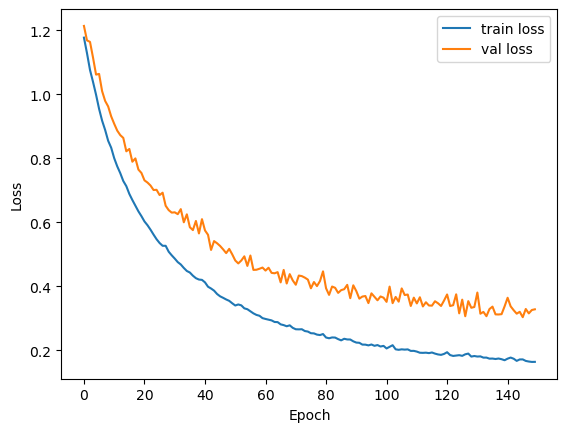

In [285]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

### Model Evaluation on Test Data

After training the model, we evaluate its performance on unseen test dataset.

This shows that the average error is about $29,430.



In [286]:
test_loss, test_mae = model.evaluate(x_test, y_test, verbose=0)
print('Test MAE:', test_mae)

Test MAE: 0.2943549156188965


### Final Model Training With Combined Datasets

After validating the model hyperparameters, I retrain the model using train and validation datasets combined.



In [287]:
x_train_full = np.concatenate((x_train, x_val), axis=0)
y_train_full = np.concatenate((y_train, y_val), axis=0)

model = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1)
])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(x_train_full, y_train_full, epochs=160, batch_size=32, callbacks=[early_stop])

Epoch 1/160
15/15 [==============================] - 0s 528us/step - loss: 4.9779 - mae: 1.6195
Epoch 2/160
15/15 [==============================] - 0s 477us/step - loss: 2.7944 - mae: 0.8938
Epoch 3/160
15/15 [==============================] - 0s 438us/step - loss: 2.0465 - mae: 0.6650
Epoch 4/160
15/15 [==============================] - 0s 405us/step - loss: 1.7367 - mae: 0.5598
Epoch 5/160
15/15 [==============================] - 0s 397us/step - loss: 1.5691 - mae: 0.5018
Epoch 6/160
15/15 [==============================] - 0s 400us/step - loss: 1.4562 - mae: 0.4757
Epoch 7/160
15/15 [==============================] - 0s 390us/step - loss: 1.3652 - mae: 0.4538
Epoch 8/160
15/15 [==============================] - 0s 380us/step - loss: 1.2854 - mae: 0.4317
Epoch 9/160
15/15 [==============================] - 0s 369us/step - loss: 1.2117 - mae: 0.4142
Epoch 10/160
15/15 [==============================] - 0s 366us/step - loss: 1.1527 - mae: 0.4039
Epoch 11/160
15/15 [===================

### Final Model Evaluation

Here I evaluate the new model and we can see that the test mean average errr is 0.2958.

In [288]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean average error: {test_mae:.4f}')

4/4 [==============================] - 0s 640us/step - loss: 0.4101 - mae: 0.2958
Test mean average error: 0.2958


## Conclusion

Things I tested to improve the model:

- **Dropout**: Seemed to consistently increase the mean average error value.
- **Batch Normalization**: Helped when I had lower neuron count but the results became even better after removing Batch Normalization and increase neuron count
- **Kernel Regularizer**: This had the biggest effect and noticeably improved mean average error.
- **Increasing Hidden Layer and neuron count**: I first tried with 128 neurons with 2 Hidden Layers but that didn't really help. After that I tested 3 Hidden Layers with 32 neurons and 64 neurons, which ended giving a slightly better result.